In [76]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('notebooks') # This allows utilities to be used here even though it's in another folder.
from utilities import styled_plot, save_plot

# Connecting to SQLite Database

In [60]:
conn = sqlite3.connect("data/cleaned_data.sqlite")

# Joining ACS Demographic and Housing Data Tables
Joining these tables through the serial_number column combines demographic and housing data. 

In [61]:
query = """
SELECT *
FROM acsd_data AS a
JOIN acsh_data AS p
ON a.serial_number = p.serial_number
"""

Loading the query into a DataFrame.

In [62]:
acs_df = pd.read_sql_query(query, conn)

acs_df.head()

,serial_number,occupation,age,sex,race,hispanic_origin,education_level,state_fips,puma_area,employment_status,wage_income,class_of_worker,hours_per_week,needs_support,soc_code,serial_number,group_quarters_type
0,2022GQ0000029,None,10,Male,White,Not Hispanic or Latino,Grade 5,Kentucky,Lake Cumberland Area Development District (West),Unknown,0.0,Not employed,0.0,1,Not employed,2022GQ0000029,Institutional group quarters
1,2022GQ0000118,None,89,Female,White,Not Hispanic or Latino,Grade 9,Kentucky,Kentucky River Area Development District,Under 16 years old,0.0,Not employed,0.0,1,Not employed,2022GQ0000118,Institutional group quarters
2,2022GQ0000184,1240,22,Male,White,Not Hispanic or Latino,High school graduate or GED,Kentucky,Bluegrass Area Development District (South),Under 16 years old,10000.0,Not employed,35.0,1,152099,2022GQ0000184,Noninstitutional group quarters
3,2022GQ0000384,4020,48,Male,White,Not Hispanic or Latino,High school graduate or GED,Kentucky,KIPDA Area Development District (West)--Louisv...,Under 16 years old,0.0,Not employed,0.0,1,352019,2022GQ0000384,Noninstitutional group quarters
4,2022GQ0000396,None,75,Female,White,Not Hispanic or Latino,Associate's degree,Kentucky,KIPDA Area Development District (West)--Louisv...,Under 16 years old,0.0,Not employed,0.0,1,Not employed,2022GQ0000396,Institutional group quarters


## Labeling Incarcerated Individuals

**Issue:**
Housing data contains the value "Institutional group quarters", which could include prisons and jails but also medical facilities.  

**Plan:**
Now that the demographic and housing tables are merged, I can compare housing type to other demographic information to determine high likelihood that an individual is incarcerated.  
This information will be stored in a new boolean column.

### Criteria for `likely_incarcerated = True`

The `likely_incarcerated` flag is intended to identify individuals who are likely incarcerated, based on the following criteria:

- **`group_quarters_type` is `'Institutional group quarters'`**  
  Indicates the person lives in an institutional setting, which may include prisons, nursing homes, or similar facilities.

- **`age` is between 18 and 64**  
  Most nursing home and hospice residents are over 65, so this helps filter out elderly populations.

- **`wage_income` is `0`**  
  Many incarcerated individuals have no reported wage income.

Together, these filters aim to conservatively estimate incarceration status using available variables while minimizing false positives from other institutional settings.


In [63]:
acs_df['likely_incarcerated'] = (
    (acs_df['group_quarters_type'] == 'Institutional group quarters') &
    (acs_df['age'].between(18, 64)) &
    (acs_df['wage_income'] == 0)
)

acs_df.head()


,serial_number,occupation,age,sex,race,hispanic_origin,education_level,state_fips,puma_area,employment_status,wage_income,class_of_worker,hours_per_week,needs_support,soc_code,serial_number,group_quarters_type,likely_incarcerated
0,2022GQ0000029,None,10,Male,White,Not Hispanic or Latino,Grade 5,Kentucky,Lake Cumberland Area Development District (West),Unknown,0.0,Not employed,0.0,1,Not employed,2022GQ0000029,Institutional group quarters,False
1,2022GQ0000118,None,89,Female,White,Not Hispanic or Latino,Grade 9,Kentucky,Kentucky River Area Development District,Under 16 years old,0.0,Not employed,0.0,1,Not employed,2022GQ0000118,Institutional group quarters,False
2,2022GQ0000184,1240,22,Male,White,Not Hispanic or Latino,High school graduate or GED,Kentucky,Bluegrass Area Development District (South),Under 16 years old,10000.0,Not employed,35.0,1,152099,2022GQ0000184,Noninstitutional group quarters,False
3,2022GQ0000384,4020,48,Male,White,Not Hispanic or Latino,High school graduate or GED,Kentucky,KIPDA Area Development District (West)--Louisv...,Under 16 years old,0.0,Not employed,0.0,1,352019,2022GQ0000384,Noninstitutional group quarters,False
4,2022GQ0000396,None,75,Female,White,Not Hispanic or Latino,Associate's degree,Kentucky,KIPDA Area Development District (West)--Louisv...,Under 16 years old,0.0,Not employed,0.0,1,Not employed,2022GQ0000396,Institutional group quarters,False


In [64]:
# Checking these filters. How many people are in institutional group quarters?
acs_df["group_quarters_type"].value_counts()

group_quarters_type
Housing unit                       44361
Institutional group quarters        1204
Noninstitutional group quarters     1040
Name: count, dtype: int64

In [65]:
# How many people in institutional group quarters have been labeled likely incarcerated?
acs_df["likely_incarcerated"].value_counts()

likely_incarcerated
False    46101
True       504
Name: count, dtype: int64

## Saving Merged Microdata as a Table

In [66]:
# Dropping duplicated serial_number column.
acs_df = acs_df.loc[:, ~acs_df.columns.duplicated()]

# Saving data as a table in the database.
acs_df.to_sql('acs_merged', conn, if_exists='replace', index=False)

46605

In [67]:
acs_df.columns

Index(['serial_number', 'occupation', 'age', 'sex', 'race', 'hispanic_origin',
       'education_level', 'state_fips', 'puma_area', 'employment_status',
       'wage_income', 'class_of_worker', 'hours_per_week', 'needs_support',
       'soc_code', 'group_quarters_type', 'likely_incarcerated'],
      dtype='object')

# Merging ACS with Occupational Data  
Left joining acs_merged and oo_data to provide occupational data for each person.  
Keeping only the columns needed for planned visualizations.

In [68]:
# Left join using occupation and soc_code columns
query = """
SELECT 
    a.soc_code,
    a.education_level,
    a.likely_incarcerated,
    o.mean_annual_wage,
    o.percent_change,
    o.education_required,
    o.occupation
FROM acs_merged AS a
LEFT JOIN oo_data AS o
ON a.soc_code = o.occupation
"""

# Reading into a new DataFrame
all_data = pd.read_sql_query(query, conn)


In [69]:
# How many rows didn't match?
unmatched = all_data['mean_annual_wage'].isna().sum()
total = len(all_data)
print(f"{unmatched} out of {total} rows did not match ({unmatched / total:.2%}).")

26451 out of 254267 rows did not match (10.40%).


In [70]:
# Looking at a few rows that didn’t match
unmatched_sample = all_data[all_data['mean_annual_wage'].isna()].sample(10, random_state=1)
unmatched_sample[['soc_code', 'occupation', 'education_level', 'education_required']]

,soc_code,occupation,education_level,education_required
168348,514199,514199,"Some college (1+ years, no degree)",High school diploma or equivalent
115076,Not employed,None,Bachelor's degree,None
106350,Not employed,None,Unknown,None
139256,Not employed,None,"Some college (1+ years, no degree)",None
131639,Not employed,None,Grade 6,None
198691,152011,None,Doctorate,None
82120,Not employed,None,High school graduate or GED,None
43563,Not employed,None,Professional degree,None
234509,Not employed,None,Unknown,None
86529,Not employed,None,High school graduate or GED,None


## Conclusions:

- ~10% is a relatively low percentage of unmatched rows.
- ACS rows for individuals that list "Not employed" would not match with an occupation from the Occupational Outlook data.
- ACS rows containing a code not matching an Occupational Outlook code were likely entered incorrectly in the original data (confirmed by spot checking original Occupational Outlook data.)
- Some rows are labeled as "unmatched" despite having matching codes because one or more of the columns used to check matching had no value (for example, education_required).

**Plan: Given the above explanations, this merge is acceptable to proceed.**

## Mapping 'occupation' codes to descriptive job titles

Note: This was not done earlier because it presented merging issues. The tables merged more easily using straight-forward codes.

In [71]:
# Loading crosswalk
crosswalk_path = "docs/job_code_crosswalk.xlsx"
raw_crosswalk = pd.read_excel(crosswalk_path, sheet_name="NEM SOC ACS crosswalk", header=None)

# Extracting relevant rows and columns
crosswalk_df = raw_crosswalk.iloc[5:, [1, 4]]  # Columns 1 = SOC, 4 = Title
crosswalk_df.columns = ['Matrix Occupation Code', 'ACS Occupational Title']

# Cleaning and mapping
crosswalk_df['Matrix Occupation Code'] = (
    pd.to_numeric(crosswalk_df['Matrix Occupation Code'].str.replace('-', ''), errors='coerce')
    .dropna()
    .astype(int)
    .astype(str)
    .str.zfill(6)
)
crosswalk_df = crosswalk_df.dropna(subset=['ACS Occupational Title'])

occupation_map = dict(zip(crosswalk_df['Matrix Occupation Code'], crosswalk_df['ACS Occupational Title']))

# Mapping in place and re-filling nulls with 'Not employed'
all_data['occupation'] = all_data['occupation'].map(occupation_map).fillna('Not employed')

all_data['occupation'].value_counts()


occupation
Not employed                                              22121
Registered nurses                                          7271
Driver/sales workers and truck drivers                     7260
Laborers and freight, stock, and material movers, hand     6919
Other managers                                             6061
                                                          ...  
Fish and game wardens and parking enforcement officers        2
Transportation security screeners                             2
Other textile, apparel, and furnishings workers               1
Engine and other machine assemblers                           1
Avionics technicians                                          1
Name: count, Length: 480, dtype: int64

# Plots

## Education Levels by Incarceration Status (Grouped Bar Chart)

Plot saved to: plots\education_grouped_bar.png


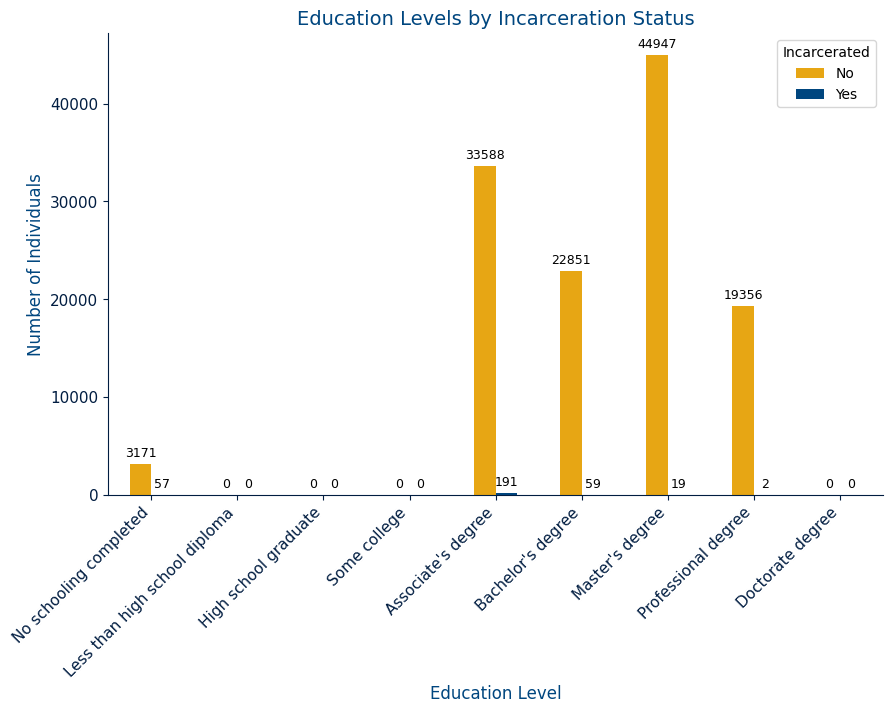

In [81]:
# Group and count
edu_counts = all_data.groupby(['education_level', 'likely_incarcerated']).size().unstack(fill_value=0)

# Put educational levels in order and fill missing data with zero
edu_counts = edu_counts.reindex([
    "No schooling completed",
    "Less than high school diploma",
    "High school graduate",
    "Some college",
    "Associate's degree",
    "Bachelor's degree",
    "Master's degree",
    "Professional degree",
    "Doctorate degree"
], fill_value=0)

# Plot setup
ax = edu_counts.plot(kind='bar', figsize=(10, 6), color=["#E7A614", "#00467F"])

# Using utilities function for plot style
plot_color = styled_plot(
    title="Education Levels by Incarceration Status",
    xlabel="Education Level",
    ylabel="Number of Individuals",
    fontsize=12
)

# More formatting
plt.xticks(rotation=45, ha='right')
plt.legend(title="Incarcerated", labels=["No", "Yes"])

# Adding labels to bars since incarcerated individuals are so few and don't show up well
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, color='black', padding=3)

# Using utilities function to save the plot
save_plot("education_grouped_bar.png")
plt.show()



## stacked bar

## bubble